House Price Dataset:
   Size  Bedrooms  Age   Price
0  1200         2   10  250000
1  1500         3    5  350000
2  1800         3    8  400000
3  2000         4    3  450000
4  2200         4    6  500000


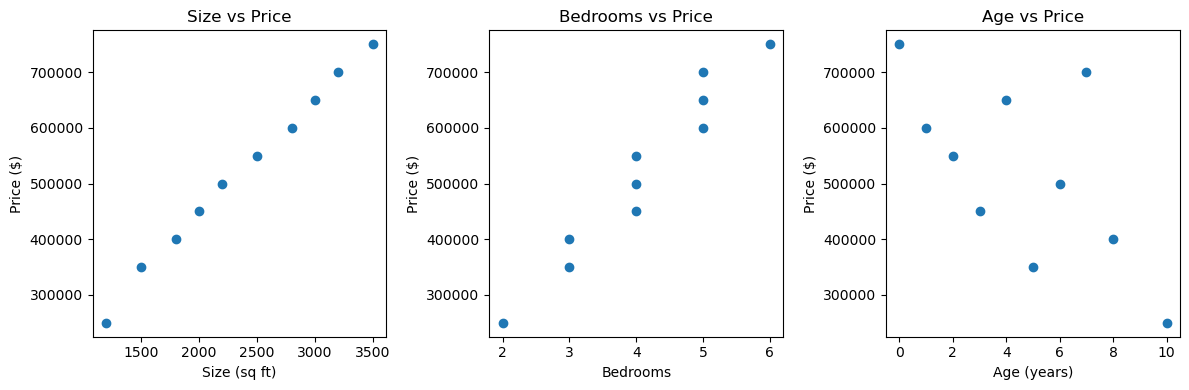


Model Evaluation:
Mean Absolute Error: $12,756.07
R-squared Score: 0.9947

Model Coefficients:
Size: 184.53
Bedrooms: 17143.08
Age: 142.93
Intercept: 9163.09

Prediction Example:
2100 sq ft, 4 bedrooms, 5 years old
Predicted Price: $465,967.92


F:\anacondaa\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


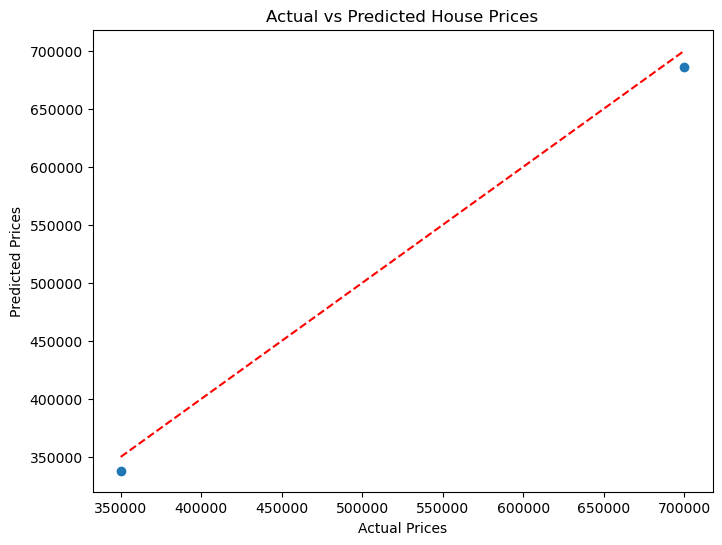

In [1]:
# Simple House Price Prediction
# Uses a clean dataset with key features

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Create a simple synthetic dataset (or replace with your own CSV)
data = {
    'Size': [1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3200, 3500],
    'Bedrooms': [2, 3, 3, 4, 4, 4, 5, 5, 5, 6],
    'Age': [10, 5, 8, 3, 6, 2, 1, 4, 7, 0],
    'Price': [250000, 350000, 400000, 450000, 500000, 550000, 600000, 650000, 700000, 750000]
}

df = pd.DataFrame(data)

# Display the dataset
print("House Price Dataset:")
print(df.head())

# Visualize the data
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(df['Size'], df['Price'])
plt.title('Size vs Price')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($)')

plt.subplot(1, 3, 2)
plt.scatter(df['Bedrooms'], df['Price'])
plt.title('Bedrooms vs Price')
plt.xlabel('Bedrooms')
plt.ylabel('Price ($)')

plt.subplot(1, 3, 3)
plt.scatter(df['Age'], df['Price'])
plt.title('Age vs Price')
plt.xlabel('Age (years)')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Prepare data for modeling
X = df[['Size', 'Bedrooms', 'Age']]  # Features
y = df['Price']  # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-squared Score: {r2:.4f}")

# Show coefficients
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

# Predict new house price
new_house = [[2100, 4, 5]]  # Size, Bedrooms, Age
predicted_price = model.predict(new_house)

print("\nPrediction Example:")
print(f"2100 sq ft, 4 bedrooms, 5 years old")
print(f"Predicted Price: ${predicted_price[0]:,.2f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Ou

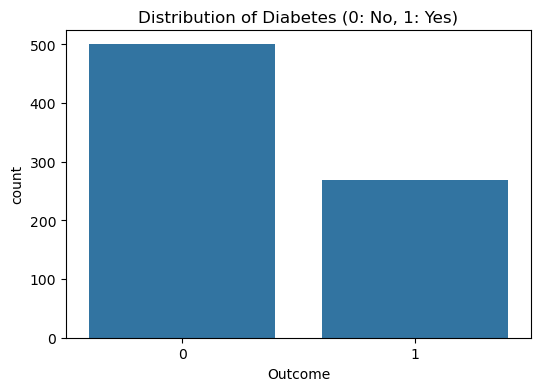

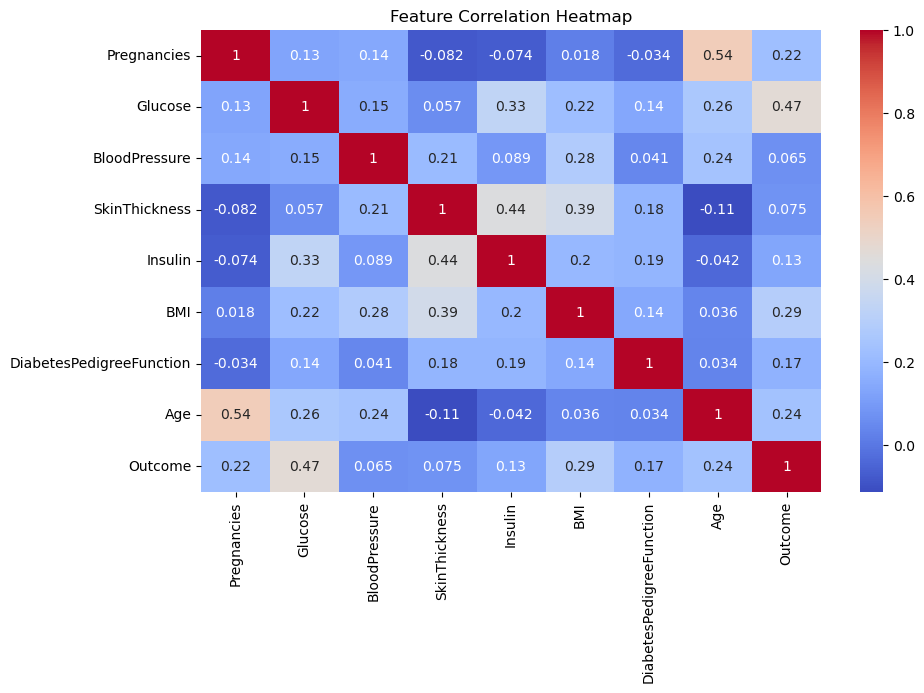


Model Accuracy: 0.7532467532467533


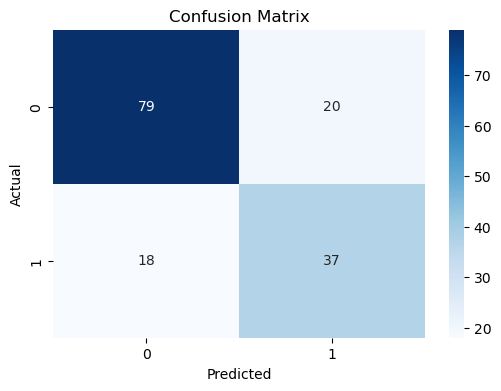


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


Example Prediction:
Does the patient have diabetes? No


F:\anacondaa\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(url, names=columns)

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Basic statistics
print("\nDataset statistics:")
print(df.describe())

# Visualize the distribution of outcomes
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Diabetes (0: No, 1: Yes)")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Prepare data for training
X = df.drop("Outcome", axis=1)  # Features
y = df["Outcome"]  # Target

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for logistic regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Example Prediction
new_patient = [[2, 120, 70, 25, 100, 26.5, 0.3, 30]]  # Sample patient data
scaled_patient = scaler.transform(new_patient)
prediction = model.predict(scaled_patient)
print("\nExample Prediction:")
print("Does the patient have diabetes?", "Yes" if prediction[0] == 1 else "No")